# CNN Backbone × DQN Algorithm — Full Cross-Comparison

Varies **both the CNN backbone and the DQN algorithm** in a full grid.
Measures **epochs to mastery** on the tutorial curriculum.

### CNN Backbones (5)
| Backbone | Change | Approx Backbone Params |
|----------|--------|----------------------|
| **Baseline** | 4-layer factored CNN (32/64/128) | ~108K |
| **Wider** | Same 4 layers, 2× channels (64/128/256) | ~416K |
| **Deeper** | 5th conv layer (2nd cross-region pass) | ~145K |
| **Residual** | Skip connections around conv2+conv3 | ~108K |
| **Narrow-Deep** | Half channels, 6 layers (16/32/64) | ~43K |

### DQN Algorithms (3)
| Algorithm | Key Difference |
|-----------|---------------|
| **Baseline** | Double DQN + PER |
| **Spectral Norm** | Spectral-normalized convolutions (fastest) |
| **Munchausen** | Reward += α·τ·log π(a\|s) (best pass rates) |

**Total: 5 × 3 = 15 runs**

In [1]:
import sys, os, time, random
import numpy as np
import torch

# Ensure project root is on path — works whether launched from
# the project root (`python -m notebook notebooks/...`) or
# from the notebooks/ directory (`jupyter notebook ...`).
_cwd = os.getcwd()
if os.path.basename(_cwd) == "notebooks":
    PROJECT_ROOT = os.path.abspath(os.path.join(_cwd, ".."))
elif os.path.isdir(os.path.join(_cwd, "simulation")):
    PROJECT_ROOT = _cwd
else:
    PROJECT_ROOT = os.path.abspath(os.path.join(_cwd, ".."))

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"Project root: {PROJECT_ROOT}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    # print(f"VRAM: {torch.cuda.get_device_properties(0).total_mem / 1024**3:.1f} GB")

Project root: /home/franko/CT-DRL-MA
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 2060 SUPER


In [2]:
from simulation.rl.agent_registry import create_agent, DQN_ALGORITHMS as _DQN_ALL
from simulation.rl.backbone_factory import BACKBONE_VARIANTS, get_cnn_config
from simulation.training.unified_curriculum_trainer import (
    create_env_factory, build_agent_config,
)
from simulation.training.unified_tutorial_runner import UnifiedTutorialRunner

print(f"Backbone variants: {BACKBONE_VARIANTS}")
print(f"DQN algorithms: {list(_DQN_ALL)}")
print("Factory: create_agent(dqn, cfg, backbone_variant=cnn)")

Backbone variants: ['baseline', 'wider', 'deeper', 'residual', 'narrow_deep']
DQN algorithms: ['baseline', 'munchausen', 'spectral_norm', 'noisynet', 'dueling', 'qrdqn', 'iqn']
Factory: create_agent(dqn, cfg, backbone_variant=cnn)


In [ ]:
# ── Configuration ──────────────────────────────────────────────────────

SEED = 42
MAX_EPOCHS = 500          # max tutorial epochs per variant
MASTERY_THRESHOLD = 0.9   # 90% pass rate over sliding window
WINDOW_SIZE = 20
MIN_EPOCHS = 10
LOG_EVERY = 25            # print progress every N epochs

# Early stopping: abort if not past this tier by this epoch
EARLY_STOP_TIER = 2       # must have mastered tier 2 ("Full chains")
EARLY_STOP_EPOCH = 120    # by epoch 120

# Full cross-product grid
CNN_BACKBONES = ["baseline", "wider", "deeper", "residual", "narrow_deep"]
DQN_ALGORITHMS = ["baseline", "spectral_norm", "munchausen"]

# Build run list: (cnn_name, dqn_name) pairs
RUN_LIST = [(cnn, dqn) for cnn in CNN_BACKBONES for dqn in DQN_ALGORITHMS]

print(f"CNN backbones: {CNN_BACKBONES}")
print(f"DQN algorithms: {DQN_ALGORITHMS}")
print(f"Total runs: {len(RUN_LIST)}")
print(f"Early stopping: must pass tier {EARLY_STOP_TIER} by epoch {EARLY_STOP_EPOCH}")

In [4]:
# ── Environment factory (shared across all variants) ──────────────────

env_factory = create_env_factory(
    rows=5, bays=58, tiers=5, tracks=7, split_factor=20,
)

# Base agent config (shared yard geometry + training defaults)
base_cfg = build_agent_config(
    rows=5, bays=58, tiers=5, split_factor=20, tracks=7,
)

print(f"Agent config device: {base_cfg.device}")
print(f"Replay buffer: {base_cfg.training.replay_size:,}")
print(f"Batch size: {base_cfg.training.batch_size}")
print(f"Gamma: {base_cfg.training.gamma}")

Agent config device: cuda
Replay buffer: 2,000
Batch size: 32
Gamma: 0.99


In [ ]:
# ── Run full cross-product grid ───────────────────────────────────────

import gc

results = {}

for run_idx, (cnn_name, dqn_name) in enumerate(RUN_LIST, 1):
    run_key = f"{cnn_name}+{dqn_name}"
    print(f"\n{'='*70}")
    print(f"  [{run_idx}/{len(RUN_LIST)}] CNN: {cnn_name.upper()}  ×  DQN: {dqn_name.upper()}")
    print(f"{'='*70}\n")

    # Seed everything for reproducibility
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED)

    # Create cross-combination agent via the composable factory
    agent = create_agent(dqn_name, base_cfg, backbone_variant=cnn_name)
    n_params = sum(p.numel() for p in agent.q_net.parameters())
    backbone_params = sum(p.numel() for p in agent.q_net.backbone.parameters())
    print(f"  Total parameters: {n_params:,}")
    print(f"  Backbone parameters: {backbone_params:,}")

    # Create runner with this agent
    runner = UnifiedTutorialRunner(
        env_factory=env_factory,
        agent_or_config=agent,
        verbose=True,
    )

    # Train
    t0 = time.time()
    summary = runner.train_all(
        epochs=MAX_EPOCHS,
        mastery_threshold=MASTERY_THRESHOLD,
        window_size=WINDOW_SIZE,
        min_epochs=MIN_EPOCHS,
        log_every=LOG_EVERY,
        early_stop_check=lambda ep, tier: ep >= EARLY_STOP_EPOCH and tier < EARLY_STOP_TIER,
    )
    wall_time = time.time() - t0

    # Store results
    early_stopped = summary.get("early_stopped", False)
    results[run_key] = {
        "cnn": cnn_name,
        "dqn": dqn_name,
        "epochs": summary["epochs_completed"],
        "mastered": summary["mastered"],
        "early_stopped": early_stopped,
        "current_tier": summary["current_tier"],
        "n_tiers": summary["n_tiers"],
        "pass_rates": summary["pass_rates"],
        "scenario_names": summary["scenario_names"],
        "wall_time_s": wall_time,
        "n_params": n_params,
        "backbone_params": backbone_params,
    }

    status = "MASTERED" if summary["mastered"] else ("EARLY STOPPED" if early_stopped else "NOT MASTERED")
    print(f"\n  Result: {status} in {summary['epochs_completed']} epochs "
          f"({wall_time:.0f}s wall time)")
    print(f"  Tier reached: {summary['current_tier']}/{summary['n_tiers']}")

    # ── Aggressive GPU cleanup ──────────────────────────────────────
    agent.q_net.cpu()
    agent.target_net.cpu()
    agent.replay_buffer = None
    del agent, runner
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        allocated = torch.cuda.memory_allocated() / 1024**2
        reserved = torch.cuda.memory_reserved() / 1024**2
        print(f"  GPU cleanup: {allocated:.0f} MB allocated, {reserved:.0f} MB reserved")

print(f"\n{'='*70}")
print("  ALL CROSS-COMBINATIONS COMPLETE")
print(f"{'='*70}")

In [5]:
# ── OPTION A: Load pre-computed results from JSON ─────────────────────
# Use this cell instead of the training cell below if you already have
# results from a previous run (e.g. parsed from logs with parse_logs.py).
#
# Usage:
#   python parse_logs.py your_logfile.txt -o cnn_dqn_results.json
#   Then run this cell instead of the training cell.

import json

RESULTS_FILE = "cnn_dqn_results.json"

with open(RESULTS_FILE) as f:
    results = json.load(f)

# Ensure mastered is bool (JSON preserves this but just in case)
for run_key, r in results.items():
    r["mastered"] = bool(r["mastered"])

print(f"Loaded {len(results)} runs from {RESULTS_FILE}")
for key, r in sorted(results.items()):
    status = "MASTERED" if r["mastered"] else "NOT MASTERED"
    print(f"  {key}: {status} in {r['epochs']} epochs ({r['wall_time_s']:.0f}s)")

Loaded 15 runs from cnn_dqn_results.json
  baseline+baseline: MASTERED in 419 epochs (5197s)
  baseline+munchausen: MASTERED in 267 epochs (2406s)
  baseline+spectral_norm: MASTERED in 316 epochs (2620s)
  deeper+baseline: NOT MASTERED in 500 epochs (6951s)
  deeper+munchausen: MASTERED in 283 epochs (1634s)
  deeper+spectral_norm: MASTERED in 336 epochs (3511s)
  narrow_deep+baseline: MASTERED in 377 epochs (2385s)
  narrow_deep+munchausen: MASTERED in 417 epochs (2570s)
  narrow_deep+spectral_norm: NOT MASTERED in 500 epochs (7446s)
  residual+baseline: MASTERED in 339 epochs (3103s)
  residual+munchausen: MASTERED in 388 epochs (3920s)
  residual+spectral_norm: MASTERED in 332 epochs (3395s)
  wider+baseline: NOT MASTERED in 500 epochs (7620s)
  wider+munchausen: NOT MASTERED in 500 epochs (8626s)
  wider+spectral_norm: MASTERED in 289 epochs (3588s)


In [6]:
# ── Summary table ─────────────────────────────────────────────────────

import pandas as pd

rows = []
for run_key, r in results.items():
    avg_rate = np.mean(list(r["pass_rates"].values()))
    rows.append({
        "CNN": r["cnn"],
        "DQN": r["dqn"],
        "Epochs": r["epochs"],
        "Mastered": "Yes" if r["mastered"] else "No",
        "Tier": f"{r['current_tier']}/{r['n_tiers']}",
        "Avg Pass Rate": f"{avg_rate:.1%}",
        "Wall Time (s)": f"{r['wall_time_s']:.0f}",
        "Total Params": f"{r['n_params']:,}",
        "Backbone Params": f"{r['backbone_params']:,}",
    })

df_summary = pd.DataFrame(rows)
df_summary = df_summary.sort_values("Epochs").reset_index(drop=True)
df_summary

,CNN,DQN,Epochs,Mastered,Tier,Avg Pass Rate,Wall Time (s),Total Params,Backbone Params
0,baseline,munchausen,267,Yes,10/10,97.4%,2406,"140,834","107,744"
1,deeper,munchausen,283,Yes,10/10,99.5%,1634,"177,890","144,800"
2,wider,spectral_norm,289,Yes,10/10,95.0%,3588,"547,906","416,192"
3,baseline,spectral_norm,316,Yes,10/10,91.0%,2620,"140,834","107,744"
4,residual,spectral_norm,332,Yes,10/10,92.9%,3395,"140,834","107,744"
5,deeper,spectral_norm,336,Yes,10/10,98.1%,3511,"177,890","144,800"
6,residual,baseline,339,Yes,10/10,97.1%,3103,"140,834","107,744"
7,narrow_deep,baseline,377,Yes,10/10,96.4%,2385,"51,666","43,312"
8,residual,munchausen,388,Yes,10/10,94.8%,3920,"140,834","107,744"
9,narrow_deep,munchausen,417,Yes,10/10,98.8%,2570,"51,666","43,312"


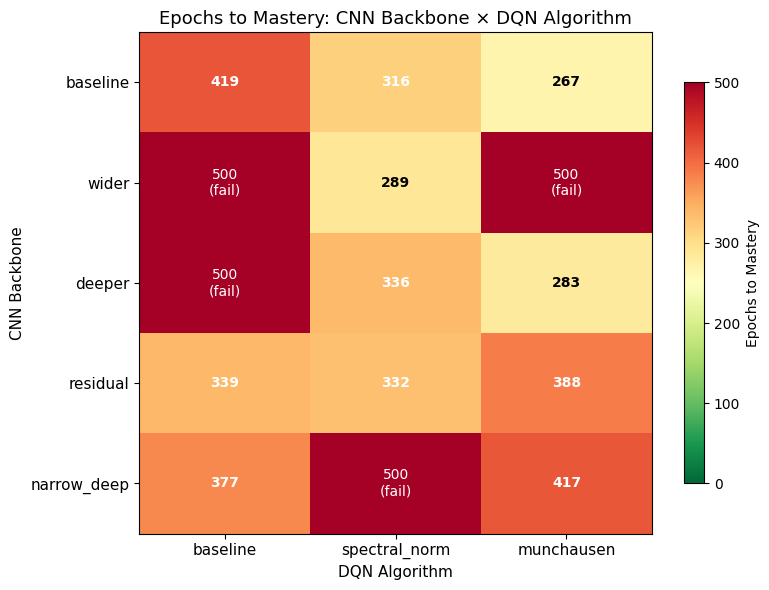

Saved: cnn_dqn_heatmap.png


In [7]:
# ── Epochs-to-mastery heatmap (CNN × DQN grid) ──────────────────────

import matplotlib.pyplot as plt
import matplotlib

# Build epochs matrix: CNN (rows) × DQN (cols)
epoch_matrix = np.full((len(CNN_BACKBONES), len(DQN_ALGORITHMS)), np.nan)
mastered_matrix = np.zeros((len(CNN_BACKBONES), len(DQN_ALGORITHMS)), dtype=bool)

for i, cnn in enumerate(CNN_BACKBONES):
    for j, dqn in enumerate(DQN_ALGORITHMS):
        key = f"{cnn}+{dqn}"
        if key in results:
            epoch_matrix[i, j] = results[key]["epochs"]
            mastered_matrix[i, j] = results[key]["mastered"]

fig, ax = plt.subplots(figsize=(8, 6))

# Use diverging colormap: green = fast, red = slow
cmap = matplotlib.colormaps["RdYlGn_r"]
im = ax.imshow(epoch_matrix, aspect="auto", cmap=cmap,
               vmin=0, vmax=MAX_EPOCHS)

ax.set_xticks(range(len(DQN_ALGORITHMS)))
ax.set_xticklabels(DQN_ALGORITHMS, fontsize=11)
ax.set_yticks(range(len(CNN_BACKBONES)))
ax.set_yticklabels(CNN_BACKBONES, fontsize=11)

# Annotate cells
for i in range(epoch_matrix.shape[0]):
    for j in range(epoch_matrix.shape[1]):
        val = epoch_matrix[i, j]
        if np.isnan(val):
            continue
        m = mastered_matrix[i, j]
        txt = f"{int(val)}" if m else f"{int(val)}\n(fail)"
        color = "white" if val > MAX_EPOCHS * 0.6 else "black"
        ax.text(j, i, txt, ha="center", va="center",
                fontsize=10, fontweight="bold" if m else "normal",
                color=color)

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Epochs to Mastery", fontsize=10)

ax.set_title("Epochs to Mastery: CNN Backbone × DQN Algorithm", fontsize=13)
ax.set_xlabel("DQN Algorithm", fontsize=11)
ax.set_ylabel("CNN Backbone", fontsize=11)

plt.tight_layout()
plt.savefig("cnn_dqn_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: cnn_dqn_heatmap.png")

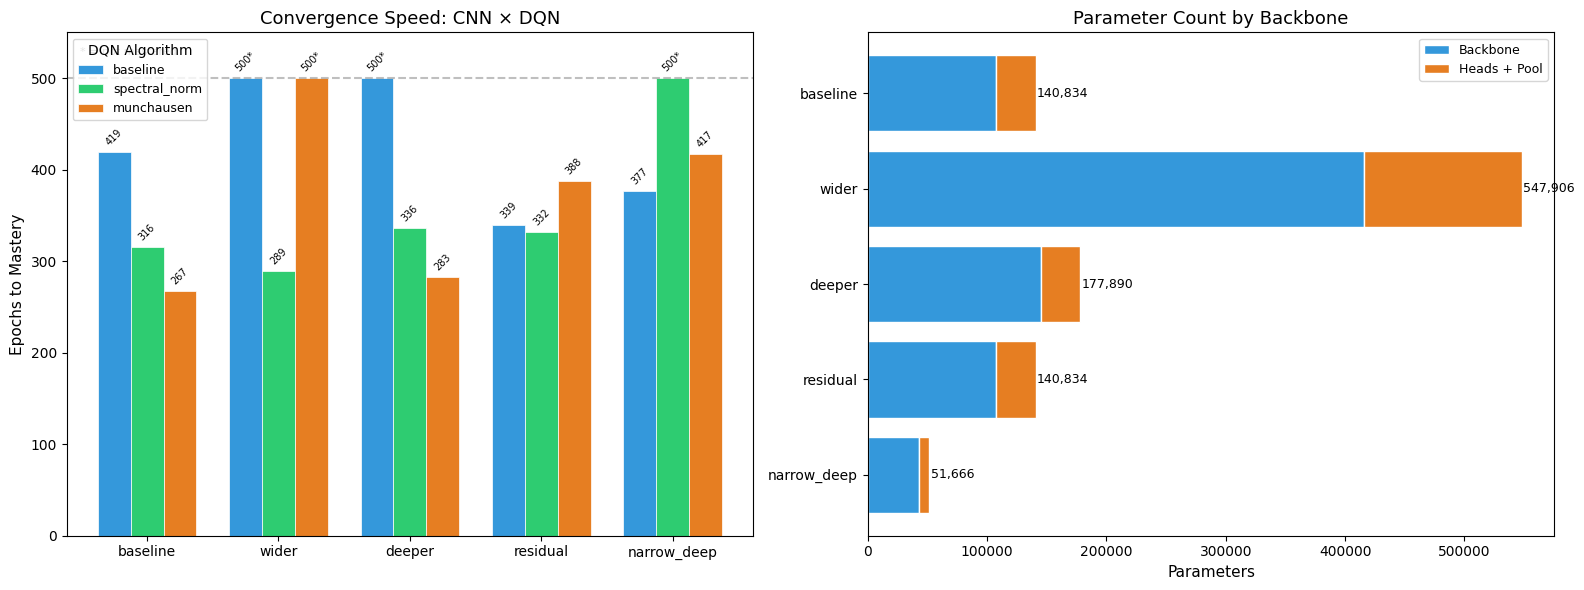

Saved: cnn_dqn_comparison.png


In [8]:
# ── Grouped bar chart: epochs by CNN backbone, grouped by DQN ────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: grouped bar chart
x = np.arange(len(CNN_BACKBONES))
width = 0.25
dqn_colors = {"baseline": "#3498db", "spectral_norm": "#2ecc71", "munchausen": "#e67e22"}

for k, dqn in enumerate(DQN_ALGORITHMS):
    epochs_list = []
    mastered_list = []
    for cnn in CNN_BACKBONES:
        key = f"{cnn}+{dqn}"
        if key in results:
            epochs_list.append(results[key]["epochs"])
            mastered_list.append(results[key]["mastered"])
        else:
            epochs_list.append(0)
            mastered_list.append(False)

    bars = ax1.bar(x + k * width, epochs_list, width, label=dqn,
                   color=dqn_colors[dqn], edgecolor="white", linewidth=0.5)

    # Add text labels
    for bar, ep, m in zip(bars, epochs_list, mastered_list):
        txt = f"{ep}" if m else f"{ep}*"
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 txt, ha="center", va="bottom", fontsize=7, rotation=45)

ax1.set_xticks(x + width)
ax1.set_xticklabels(CNN_BACKBONES, fontsize=10)
ax1.set_ylabel("Epochs to Mastery", fontsize=11)
ax1.set_title("Convergence Speed: CNN × DQN", fontsize=13)
ax1.axhline(y=MAX_EPOCHS, color="gray", linestyle="--", alpha=0.5)
ax1.legend(title="DQN Algorithm", fontsize=9)
ax1.set_ylim(0, MAX_EPOCHS * 1.1)
ax1.text(0.02, 0.97, "* = not mastered", transform=ax1.transAxes,
         fontsize=8, va="top", color="gray")

# Right: parameter count comparison
param_data = []
for cnn in CNN_BACKBONES:
    key = f"{cnn}+baseline"
    if key in results:
        param_data.append({
            "CNN": cnn,
            "Backbone": results[key]["backbone_params"],
            "Heads+Pool": results[key]["n_params"] - results[key]["backbone_params"],
        })

if param_data:
    cnn_names = [d["CNN"] for d in param_data]
    backbone_p = [d["Backbone"] for d in param_data]
    head_p = [d["Heads+Pool"] for d in param_data]

    y_pos = np.arange(len(cnn_names))
    ax2.barh(y_pos, backbone_p, label="Backbone", color="#3498db", edgecolor="white")
    ax2.barh(y_pos, head_p, left=backbone_p, label="Heads + Pool", color="#e67e22", edgecolor="white")

    for i, (b, h) in enumerate(zip(backbone_p, head_p)):
        ax2.text(b + h + 1000, i, f"{b + h:,}", va="center", fontsize=9)

    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(cnn_names, fontsize=10)
    ax2.set_xlabel("Parameters", fontsize=11)
    ax2.set_title("Parameter Count by Backbone", fontsize=13)
    ax2.legend(fontsize=9)
    ax2.invert_yaxis()

plt.tight_layout()
plt.savefig("cnn_dqn_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: cnn_dqn_comparison.png")

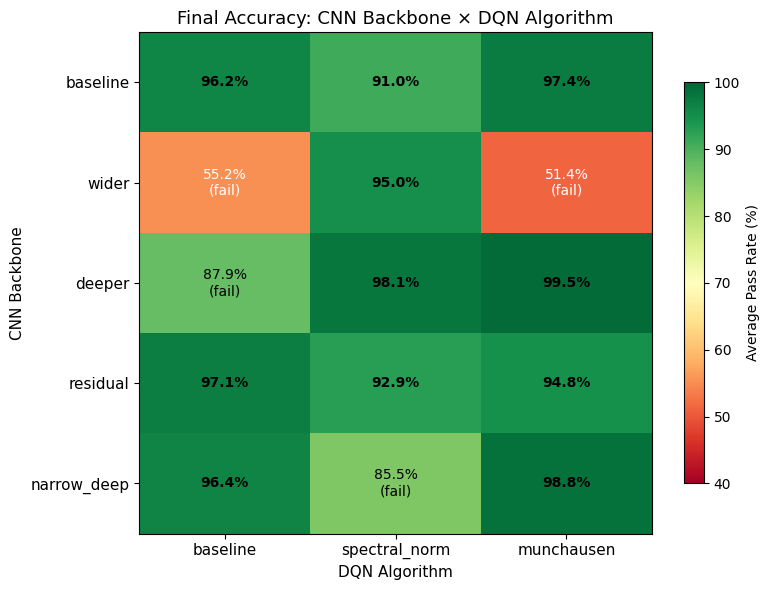

Saved: cnn_dqn_accuracy_heatmap.png


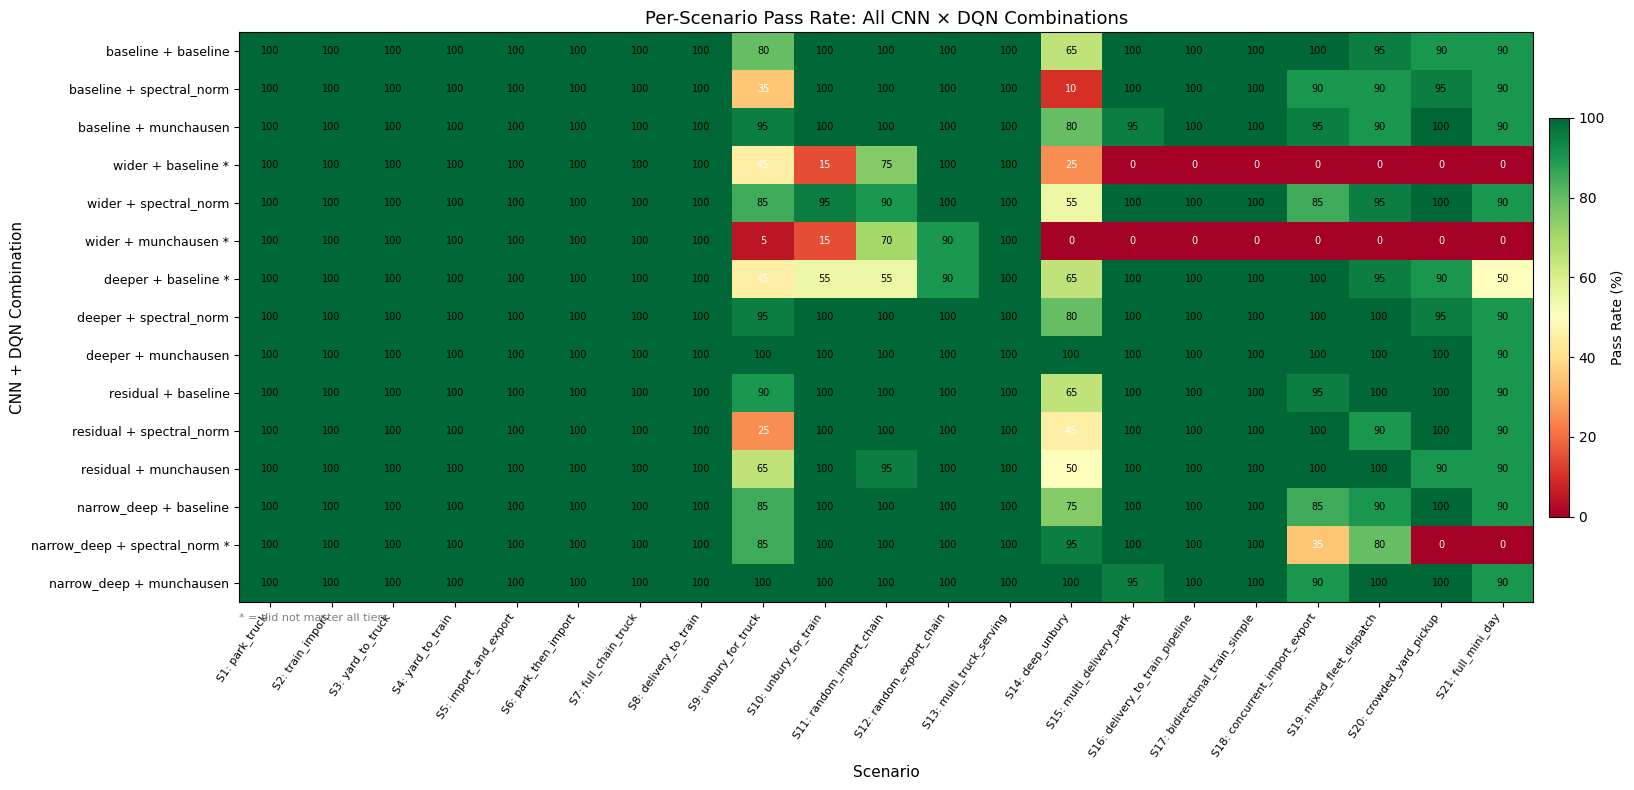

Saved: cnn_dqn_accuracy_scenarios.png


In [9]:
# ── Accuracy comparison: heatmap + per-scenario breakdown ─────────────

import matplotlib.pyplot as plt
import matplotlib
import numpy as np

# ---------- Figure 1: Average accuracy heatmap (CNN × DQN) ----------

acc_matrix = np.full((len(CNN_BACKBONES), len(DQN_ALGORITHMS)), np.nan)
mastered_matrix_acc = np.zeros((len(CNN_BACKBONES), len(DQN_ALGORITHMS)), dtype=bool)

for i, cnn in enumerate(CNN_BACKBONES):
    for j, dqn in enumerate(DQN_ALGORITHMS):
        key = f"{cnn}+{dqn}"
        if key in results:
            rates = list(results[key]["pass_rates"].values())
            acc_matrix[i, j] = np.mean(rates) * 100
            mastered_matrix_acc[i, j] = results[key]["mastered"]

fig, ax = plt.subplots(figsize=(8, 6))
cmap = matplotlib.colormaps["RdYlGn"]
im = ax.imshow(acc_matrix, aspect="auto", cmap=cmap, vmin=40, vmax=100)

ax.set_xticks(range(len(DQN_ALGORITHMS)))
ax.set_xticklabels(DQN_ALGORITHMS, fontsize=11)
ax.set_yticks(range(len(CNN_BACKBONES)))
ax.set_yticklabels(CNN_BACKBONES, fontsize=11)

for i in range(acc_matrix.shape[0]):
    for j in range(acc_matrix.shape[1]):
        val = acc_matrix[i, j]
        if np.isnan(val):
            continue
        m = mastered_matrix_acc[i, j]
        txt = f"{val:.1f}%"
        if not m:
            txt += "\n(fail)"
        color = "white" if val < 65 else "black"
        ax.text(j, i, txt, ha="center", va="center",
                fontsize=10, fontweight="bold" if m else "normal",
                color=color)

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Average Pass Rate (%)", fontsize=10)

ax.set_title("Final Accuracy: CNN Backbone × DQN Algorithm", fontsize=13)
ax.set_xlabel("DQN Algorithm", fontsize=11)
ax.set_ylabel("CNN Backbone", fontsize=11)

plt.tight_layout()
plt.savefig("cnn_dqn_accuracy_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: cnn_dqn_accuracy_heatmap.png")

# ---------- Figure 2: Per-scenario pass rates for all combinations ---

# Build scenario labels (sorted by id)
scenario_ids = sorted(results[next(iter(results))]["pass_rates"].keys(),
                      key=lambda x: int(x))
scenario_labels = []
scenario_names_map = results[next(iter(results))].get("scenario_names", {})
for sid in scenario_ids:
    name = scenario_names_map.get(sid, f"S{sid}")
    scenario_labels.append(f"S{sid}: {name}")

# Build per-combo rates matrix: combos (rows) × scenarios (cols)
combo_keys = []
combo_labels = []
rate_matrix = []
for cnn in CNN_BACKBONES:
    for dqn in DQN_ALGORITHMS:
        key = f"{cnn}+{dqn}"
        if key in results:
            combo_keys.append(key)
            m_flag = "" if results[key]["mastered"] else " *"
            combo_labels.append(f"{cnn} + {dqn}{m_flag}")
            row = [results[key]["pass_rates"].get(sid, 0.0) for sid in scenario_ids]
            rate_matrix.append(row)

rate_matrix = np.array(rate_matrix) * 100  # to percent

fig, ax = plt.subplots(figsize=(18, 8))
cmap = matplotlib.colormaps["RdYlGn"]
im = ax.imshow(rate_matrix, aspect="auto", cmap=cmap, vmin=0, vmax=100)

ax.set_xticks(range(len(scenario_labels)))
ax.set_xticklabels(scenario_labels, fontsize=8, rotation=55, ha="right")
ax.set_yticks(range(len(combo_labels)))
ax.set_yticklabels(combo_labels, fontsize=9)

# Annotate each cell
for i in range(rate_matrix.shape[0]):
    for j in range(rate_matrix.shape[1]):
        val = rate_matrix[i, j]
        color = "white" if val < 50 else "black"
        ax.text(j, i, f"{val:.0f}", ha="center", va="center",
                fontsize=7, color=color)

cbar = fig.colorbar(im, ax=ax, shrink=0.7, pad=0.01)
cbar.set_label("Pass Rate (%)", fontsize=10)

ax.set_title("Per-Scenario Pass Rate: All CNN × DQN Combinations", fontsize=13)
ax.set_xlabel("Scenario", fontsize=11)
ax.set_ylabel("CNN + DQN Combination", fontsize=11)
ax.text(0.0, -0.02, "* = did not master all tiers", transform=ax.transAxes,
        fontsize=8, va="top", color="gray")

plt.tight_layout()
plt.savefig("cnn_dqn_accuracy_scenarios.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: cnn_dqn_accuracy_scenarios.png")

In [13]:
# ── Save raw results to JSON ─────────────────────────────────────────

import json

serializable = {}
for run_key, r in results.items():
    serializable[run_key] = {
        **r,
        "pass_rates": {str(k): v for k, v in r["pass_rates"].items()},
        "scenario_names": {str(k): v for k, v in r["scenario_names"].items()},
    }

with open("cnn_dqn_results.json", "w") as f:
    json.dump(serializable, f, indent=2)

print("Saved: cnn_dqn_results.json")
print(f"\nDone! {len(results)} cross-combination runs completed.")
print("Check the summary table, heatmap, and grouped bar chart above.")

Saved: cnn_dqn_results.json

Done! 15 cross-combination runs completed.
Check the summary table, heatmap, and grouped bar chart above.
